# 12b Visualize Matched Ratio

`12-ratio_with_matched_scan.py` の保存結果を読んで、
matched high-precision scan を使った

```math
\frac{\phi_{\rm needed}}{\phi_{\rm amp,max}}
```

を図で確認する notebook です。

これは `08/08b` の修正版ではなく、その続きとしての再評価です。
        


In [1]:
from pathlib import Path
import csv
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
CSV_PATH = ROOT / "results/12-ratio-with-matched-scan/matched_ratio_scan.csv"


def read_csv(path):
    with path.open() as f:
        return list(csv.DictReader(f))


rows = read_csv(CSV_PATH)
case_rows = defaultdict(list)
for row in rows:
    case_rows[row["case_name"]].append(row)

case_names = sorted(case_rows)
case_names
        


['nphi_1_Lcut_800',
 'nphi_1_no_cut',
 'nphi_2_Lcut_800',
 'nphi_2_no_cut',
 'nphi_3_Lcut_800',
 'nphi_3_no_cut']

## Matched ratio


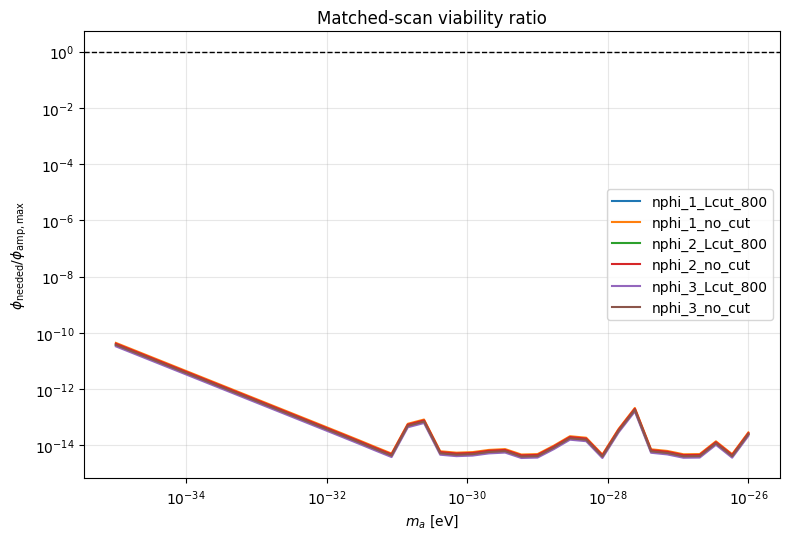

In [2]:
plt.figure(figsize=(8, 5.5))
plt.axhline(1.0, color="black", ls="--", lw=1.0)

for case_name in case_names:
    items = sorted(case_rows[case_name], key=lambda r: float(r["mass_eV"]))
    masses = np.array([float(r["mass_eV"]) for r in items])
    ratios = np.array([float(r["ratio_phi_needed_over_phi_amp_max"]) for r in items])
    plt.loglog(masses, ratios, label=case_name)

plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$\phi_{\rm needed}/\phi_{\rm amp,max}$")
plt.title(r"Matched-scan viability ratio")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## Matched breakdown


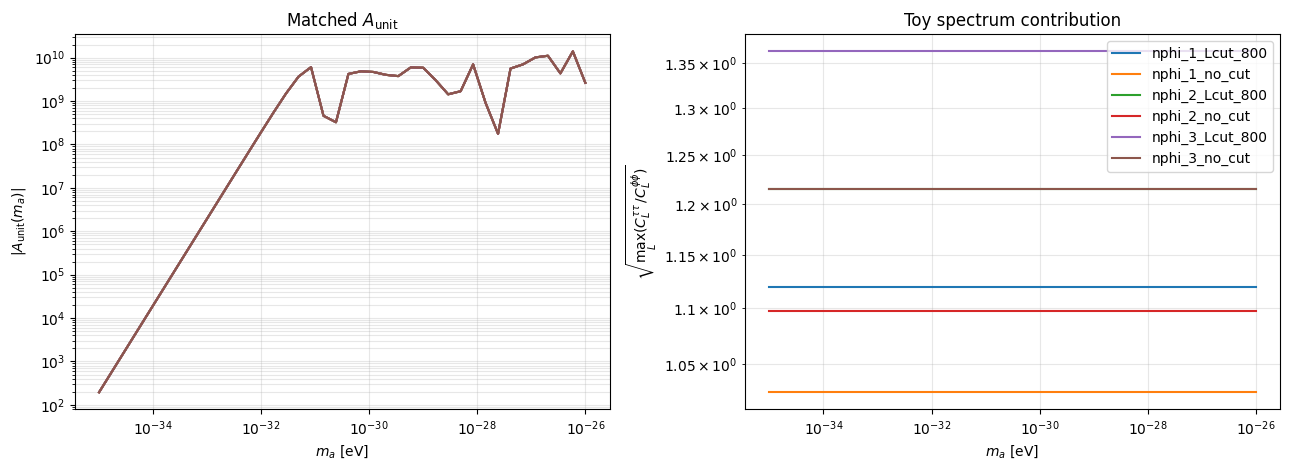

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

for case_name in case_names:
    items = sorted(case_rows[case_name], key=lambda r: float(r["mass_eV"]))
    masses = np.array([float(r["mass_eV"]) for r in items])
    a_abs = np.array([abs(float(r["A_unit"])) for r in items])
    sqrt_spec = np.sqrt(np.array([float(r["spectrum_ratio_at_peak"]) for r in items]))
    axes[0].loglog(masses, a_abs, label=case_name)
    axes[1].loglog(masses, sqrt_spec, label=case_name)

axes[0].set_xlabel(r"$m_a\ [{\rm eV}]$")
axes[0].set_ylabel(r"$|A_{\rm unit}(m_a)|$")
axes[0].set_title(r"Matched $A_{\rm unit}$")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].set_xlabel(r"$m_a\ [{\rm eV}]$")
axes[1].set_ylabel(r"$\sqrt{\max_L(C_L^{\tau\tau}/C_L^{\phi\phi})}$")
axes[1].set_title(r"Toy spectrum contribution")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
        


## Summary table


In [4]:
summary = []
for case_name in case_names:
    items = sorted(case_rows[case_name], key=lambda r: float(r["ratio_phi_needed_over_phi_amp_max"]))
    best = items[0]
    worst = items[-1]
    summary.append(
        {
            "case": case_name,
            "min_ratio_mass_eV": float(best["mass_eV"]),
            "min_ratio": float(best["ratio_phi_needed_over_phi_amp_max"]),
            "max_ratio_mass_eV": float(worst["mass_eV"]),
            "max_ratio": float(worst["ratio_phi_needed_over_phi_amp_max"]),
        }
    )

summary
        


[{'case': 'nphi_1_Lcut_800',
  'min_ratio_mass_eV': 8.376776400682924e-29,
  'min_ratio': 4.299942848799346e-15,
  'max_ratio_mass_eV': 1e-35,
  'max_ratio': 4.0169209437546476e-11},
 {'case': 'nphi_1_no_cut',
  'min_ratio_mass_eV': 8.376776400682924e-29,
  'min_ratio': 4.69426106773242e-15,
  'max_ratio_mass_eV': 1e-35,
  'max_ratio': 4.385285168078832e-11},
 {'case': 'nphi_2_Lcut_800',
  'min_ratio_mass_eV': 8.376776400682924e-29,
  'min_ratio': 3.962566095696072e-15,
  'max_ratio_mass_eV': 1e-35,
  'max_ratio': 3.701750302392545e-11},
 {'case': 'nphi_2_no_cut',
  'min_ratio_mass_eV': 8.376776400682924e-29,
  'min_ratio': 4.387447166584893e-15,
  'max_ratio_mass_eV': 1e-35,
  'max_ratio': 4.0986657341254946e-11},
 {'case': 'nphi_3_Lcut_800',
  'min_ratio_mass_eV': 8.376776400682924e-29,
  'min_ratio': 3.531087751636877e-15,
  'max_ratio_mass_eV': 1e-35,
  'max_ratio': 3.298671829497977e-11},
 {'case': 'nphi_3_no_cut',
  'min_ratio_mass_eV': 8.376776400682924e-29,
  'min_ratio': 3.962